# Predicción de Precio de Productos
## Joyería Diana Laura — Regresión con Random Forest

Este notebook implementa un modelo de regresión para predecir el `precio_venta` de un producto nuevo a partir de sus características físicas y de fabricación (material, categoría, peso, días de fabricación, personalización).

## 1. Importación de librerías

In [1]:
import os
import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from dotenv import load_dotenv

load_dotenv()
print('Librerias cargadas correctamente')

Librerias cargadas correctamente


## 2. Conexión a la base de datos

In [2]:
DATABASE_URL = os.getenv('DATABASE_URL')

conn = psycopg2.connect(DATABASE_URL)
print('Conexion exitosa a Supabase')

Conexion exitosa a Supabase


## 3. Extracción de productos

In [3]:
query = """
    SELECT
        p.id,
        p.nombre,
        p.material_principal,
        c.nombre AS categoria,
        p.peso_gramos,
        p.dias_fabricacion,
        p.permite_personalizacion,
        p.precio_venta
    FROM productos p
    JOIN categorias c ON p.categoria_id = c.id
    WHERE p.activo = true
    ORDER BY p.id
"""

df = pd.read_sql(query, conn)
print(f'Total de productos obtenidos: {len(df)}')
df

Total de productos obtenidos: 50


C:\Users\uriel\AppData\Local\Temp\ipykernel_26168\1356234066.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,id,nombre,material_principal,categoria,peso_gramos,dias_fabricacion,permite_personalizacion,precio_venta
0,1,Esclava personalizada Día del Padre,Plata,esclavas,6.2,0,True,900.55
1,2,Aretes corazón doble plata,Plata,Aretes,2.5,0,False,219.42
2,3,Pulsera personalizada Día del Niño,Acero/cuentas plásticas (bisutería),Pulseras,1.5,0,True,55.76
3,4,Esclava laminado de oro figaro,Laminado de oro,esclavas,12.5,0,False,849.40
4,6,Anillo plata solitario clásico,Plata,Anillos,4.5,0,False,450.30
5,8,Anillo plata piedra corazón rosa,Plata,Anillos,4.8,0,False,480.32
6,9,Anillo plata ley .925 corazón amatista,Plata ley .925,Anillos,5.5,0,False,580.32
7,10,Aretes plata ley .925 cristal azul y corazón f...,Plata ley .925,Aretes,3.0,0,False,300.80
8,11,Aretitos plata corazón filigrana morado,Plata,Aretes,2.1,0,False,150.40
9,12,Aretitos plata gota filigrana con perla,Plata,Aretes,2.3,0,False,200.00


## 4. Exploración de datos

Nota: el catálogo incluye productos reales y productos **sintéticos** (marcados con el prefijo `[DEMO]` en el nombre, sin `imagen_principal`). Se generaron con el consentimiento del profesor como datos de demostración, porque el catálogo real actual (15 productos) es insuficiente para entrenar un modelo de regresión de forma confiable. Los precios sintéticos se calibraron con la relación precio/gramo de los productos reales por material, **acotados al rango real observado (máx. ~$950, igual que el máximo real de $900.55)** y distribuidos equitativamente entre las 5 categorías (7 por categoría), para evitar outliers artificiales que distorsionen el entrenamiento.

In [4]:
print('=== RESUMEN DE DATOS ===')
print(f'Total de productos: {len(df)}')
print(f'Productos reales: {len(df[~df["nombre"].str.startswith("[DEMO]")])}')
print(f'Productos sinteticos (demo): {len(df[df["nombre"].str.startswith("[DEMO]")])}')
print()
print('=== MATERIALES ===')
print(df['material_principal'].value_counts())
print()
print('=== CATEGORIAS ===')
print(df['categoria'].value_counts())
print()
print('=== ESTADISTICAS DE PRECIO_VENTA (variable a predecir) ===')
print(df['precio_venta'].describe())

=== RESUMEN DE DATOS ===
Total de productos: 50
Productos reales: 15
Productos sinteticos (demo): 35

=== MATERIALES ===
material_principal
Plata                                  12
Chapa de oro                           11
Plata ley .925                         10
Laminado de oro                         7
Baño en rodio                           7
Acero/cuentas plásticas (bisutería)     3
Name: count, dtype: int64

=== CATEGORIAS ===
categoria
Anillos     15
Aretes      11
esclavas     9
Pulseras     8
Collares     7
Name: count, dtype: int64

=== ESTADISTICAS DE PRECIO_VENTA (variable a predecir) ===
count     50.000000
mean     498.797600
std      270.356225
min       55.760000
25%      242.215000
50%      465.310000
75%      779.427500
max      950.000000
Name: precio_venta, dtype: float64


## 5. Preparación de variables (One-Hot Encoding + Estandarización)

In [5]:
df_features = df.copy()

# One-Hot Encoding para variables categoricas SIN orden real (material, categoria).
# Mismo criterio que en el sistema de recomendacion: LabelEncoder introduciria una
# relacion de orden falsa entre categorias nominales.
dummies_material = pd.get_dummies(df_features['material_principal'], prefix='material')
dummies_categoria = pd.get_dummies(df_features['categoria'], prefix='categoria')

df_features['personalizacion_enc'] = df['permite_personalizacion'].astype(int)

# Estandarizacion de peso y dias de fabricacion (media 0, desviacion 1)
numericas = df_features[['peso_gramos', 'dias_fabricacion']]
scaler = StandardScaler()
numericas_escaladas = pd.DataFrame(
    scaler.fit_transform(numericas),
    columns=['peso_gramos_esc', 'dias_fabricacion_esc'],
    index=df_features.index
)

X = pd.concat([
    dummies_material,
    dummies_categoria,
    numericas_escaladas,
    df_features['personalizacion_enc']
], axis=1)

y = df['precio_venta']

print('=== VARIABLES X PREPARADAS ===')
print(X.head())
print(f'Dimensiones de X: {X.shape}')
print(f'Dimensiones de y: {y.shape}')

=== VARIABLES X PREPARADAS ===
   material_Acero/cuentas plásticas (bisutería)  material_Baño en rodio  \
0                                         False                   False   
1                                         False                   False   
2                                          True                   False   
3                                         False                   False   
4                                         False                   False   

   material_Chapa de oro  material_Laminado de oro  material_Plata  \
0                  False                     False            True   
1                  False                     False            True   
2                  False                     False           False   
3                  False                      True           False   
4                  False                     False            True   

   material_Plata ley .925  categoria_Anillos  categoria_Aretes  \
0                    False    

## 6. División en entrenamiento y prueba

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Productos de entrenamiento: {len(X_train)}')
print(f'Productos de prueba: {len(X_test)}')

Productos de entrenamiento: 40
Productos de prueba: 10


## 7. Entrenamiento del modelo — Random Forest Regressor

In [7]:
modelo_rf = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42)
modelo_rf.fit(X_train, y_train)

print('Modelo Random Forest entrenado')

Modelo Random Forest entrenado


## 8. Evaluación del modelo

Con un catálogo de 50 productos (15 reales + 35 sintéticos), el conjunto de prueba es pequeño (10 productos), por lo que estas métricas son una referencia orientativa, no una validación estadística robusta. Aun así, permiten verificar que el modelo aprende un patrón coherente y no está prediciendo al azar.

In [8]:
y_pred = modelo_rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('=== METRICAS DEL MODELO ===')
print(f'MAE  (Error Absoluto Medio):      ${mae:.2f}')
print(f'RMSE (Raiz del Error Cuadratico): ${rmse:.2f}')
print(f'R2   (Varianza explicada):        {r2:.3f}')

comparacion = pd.DataFrame({
    'precio_real': y_test.values,
    'precio_predicho': y_pred.round(2),
    'diferencia': (y_test.values - y_pred).round(2)
})
print()
print(comparacion.to_string(index=False))

=== METRICAS DEL MODELO ===
MAE  (Error Absoluto Medio):      $110.90
RMSE (Raiz del Error Cuadratico): $160.80
R2   (Varianza explicada):        0.579

 precio_real  precio_predicho  diferencia
      550.68           573.06      -22.38
      152.66           226.41      -73.75
      496.12           479.96       16.16
      752.24           750.42        1.82
      363.94           367.14       -3.20
      259.00           531.77     -272.77
      364.83           734.04     -369.21
      950.00           841.42      108.58
      177.91           279.12     -101.21
      222.95           362.92     -139.97


## 8.1 Validación cruzada (evaluación más robusta con dataset pequeño)

Un solo split train/test (arriba) depende de qué productos le tocaron al azar al conjunto de prueba — con solo 10 productos, un único caso difícil puede distorsionar la métrica. La **validación cruzada (K-Fold)** entrena y evalúa el modelo 5 veces con particiones distintas y promedia el resultado, dando una estimación más estable del desempeño real del modelo.

In [9]:
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores = cross_val_score(modelo_rf, X, y, cv=kf, scoring='r2')
mae_scores = -cross_val_score(modelo_rf, X, y, cv=kf, scoring='neg_mean_absolute_error')

print('=== VALIDACION CRUZADA (5 folds) ===')
print(f'R2 por fold:  {[round(s, 3) for s in r2_scores]}')
print(f'R2 promedio:  {r2_scores.mean():.3f} (+/- {r2_scores.std():.3f})')
print()
print(f'MAE por fold: {[round(s, 2) for s in mae_scores]}')
print(f'MAE promedio: ${mae_scores.mean():.2f} (+/- ${mae_scores.std():.2f})')

=== VALIDACION CRUZADA (5 folds) ===
R2 por fold:  [np.float64(0.519), np.float64(0.837), np.float64(0.73), np.float64(0.907), np.float64(0.788)]
R2 promedio:  0.756 (+/- 0.132)

MAE por fold: [np.float64(120.44), np.float64(71.23), np.float64(100.25), np.float64(76.75), np.float64(89.74)]
MAE promedio: $91.68 (+/- $17.58)


## 9. Importancia de variables

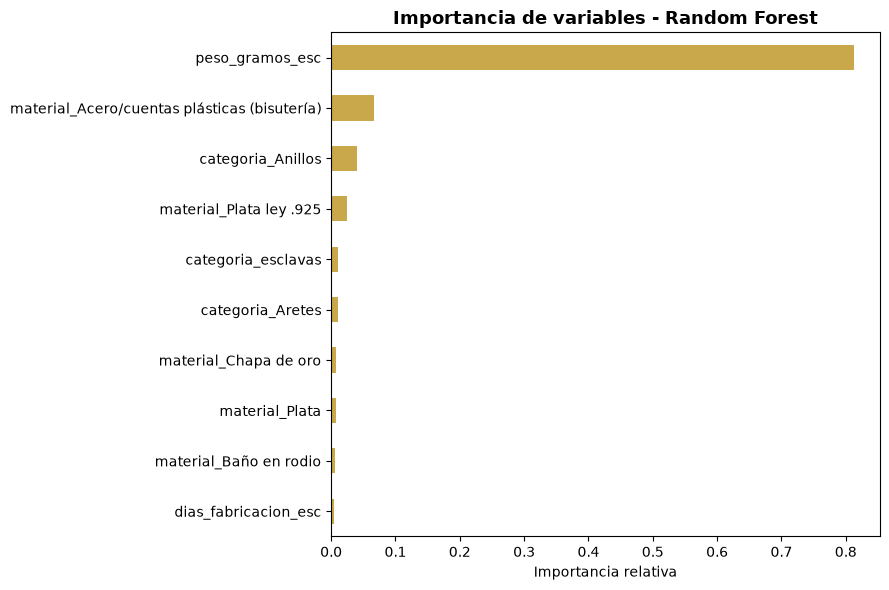

peso_gramos_esc                                 0.812541
material_Acero/cuentas plásticas (bisutería)    0.067216
categoria_Anillos                               0.040596
material_Plata ley .925                         0.024314
categoria_esclavas                              0.011223
categoria_Aretes                                0.010121
material_Chapa de oro                           0.007735
material_Plata                                  0.007243
material_Baño en rodio                          0.006085
dias_fabricacion_esc                            0.004822
dtype: float64


In [10]:
importancias = pd.Series(modelo_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
importancias.head(10).plot(kind='barh', ax=ax, color='#c9a84c')
ax.set_title('Importancia de variables - Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia relativa')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(importancias.head(10))

## 10. Prueba del sistema — predicción para un producto nuevo

In [11]:
def predecir_precio(material, categoria, peso_gramos, dias_fabricacion, permite_personalizacion):
    fila = pd.DataFrame([{
        'material_principal': material,
        'categoria': categoria,
        'peso_gramos': peso_gramos,
        'dias_fabricacion': dias_fabricacion,
        'permite_personalizacion': permite_personalizacion
    }])

    dummies_mat = pd.get_dummies(fila['material_principal'], prefix='material')
    dummies_cat = pd.get_dummies(fila['categoria'], prefix='categoria')
    fila['personalizacion_enc'] = fila['permite_personalizacion'].astype(int)

    numericas_fila = scaler.transform(fila[['peso_gramos', 'dias_fabricacion']])
    numericas_fila = pd.DataFrame(numericas_fila, columns=['peso_gramos_esc', 'dias_fabricacion_esc'])

    fila_X = pd.concat([dummies_mat, dummies_cat, numericas_fila, fila['personalizacion_enc']], axis=1)
    # Reindexar para que tenga exactamente las mismas columnas que X (rellena con 0 las que falten)
    fila_X = fila_X.reindex(columns=X.columns, fill_value=0)

    precio = modelo_rf.predict(fila_X)[0]
    return round(precio, 2)


ejemplo = predecir_precio('Plata', 'Anillos', peso_gramos=5.0, dias_fabricacion=0, permite_personalizacion=False)
print('Producto: Anillo de Plata, 5g, sin personalizacion')
print(f'Precio sugerido: ${ejemplo}')
print()

ejemplo2 = predecir_precio('Chapa de oro', 'esclavas', peso_gramos=10.0, dias_fabricacion=5, permite_personalizacion=True)
print('Producto: Esclava de Chapa de oro, 10g, personalizable')
print(f'Precio sugerido: ${ejemplo2}')

Producto: Anillo de Plata, 5g, sin personalizacion
Precio sugerido: $607.56

Producto: Esclava de Chapa de oro, 10g, personalizable
Precio sugerido: $886.75


## 11. Guardar el modelo

In [12]:
modelo = {
    'modelo_rf': modelo_rf,
    'scaler': scaler,
    'columnas_X': list(X.columns),
    'mae': mae,
}

with open('modelo_prediccion_precio.pkl', 'wb') as f:
    pickle.dump(modelo, f)

print('Modelo guardado como modelo_prediccion_precio.pkl')

Modelo guardado como modelo_prediccion_precio.pkl


## 12. Conclusiones

El sistema de predicción de precio basado en **Random Forest Regressor** fue implementado para Joyería Diana Laura, permitiendo al administrador obtener un precio sugerido automáticamente al dar de alta un producto nuevo, a partir de sus características físicas y de fabricación.

**Variables utilizadas (X):**
- `material_principal` y `categoria` — codificadas con **One-Hot Encoding** (mismo criterio que en la Propuesta 1: no existe un orden real entre categorías nominales)
- `peso_gramos` y `dias_fabricacion` — **estandarizados** con `StandardScaler`
- `permite_personalizacion` — variable binaria (0/1)

**Variable a predecir (Y):** `precio_venta`

**Sobre el uso de datos sintéticos:**
El catálogo real de la joyería tiene actualmente 15 productos, un volumen insuficiente para entrenar y validar un modelo de regresión de forma confiable (no permite una división train/test significativa). Con autorización del profesor, se generaron 35 productos sintéticos adicionales (marcados con `[DEMO]`, sin imagen y con `stock_actual = 0` para que no sean comprables) para demostrar el funcionamiento del modelo con un volumen de datos más razonable (50 productos en total). Los precios sintéticos no son arbitrarios: se calibraron usando la relación precio-por-gramo observada en los productos reales de cada material, **acotados al rango de precio real (máx. ~$950)** y balanceados entre las 5 categorías (7 productos por categoría) para evitar que una categoría con pocos ejemplos (como el caso inicial de Collares) genere predicciones erráticas. Estos productos deben archivarse (`activo = false`) una vez concluida la etapa de demostración.

**Sobre la validación cruzada:** además de la división train/test tradicional, se incluyó **K-Fold cross-validation (5 folds)**, que da una estimación más estable del desempeño del modelo al promediar 5 evaluaciones con particiones distintas — importante con un dataset pequeño, donde un solo split puede ser engañoso por casualidad.

**Limitación honesta:** incluso con 50 productos balanceados, el volumen de datos sigue siendo pequeño para un modelo de producción robusto. Las métricas (MAE, RMSE, R²) deben interpretarse como una referencia orientativa del comportamiento del modelo, no como una garantía de precisión definitiva. La calidad del modelo mejorará de forma natural conforme el catálogo real crezca.

**Siguiente paso:** igual que en la Propuesta 1, el microservicio Flask en producción no cargará este `.pkl` directamente — se recomienda entrenar el modelo en tiempo real con cada solicitud, consultando la base de datos actual, para que el precio sugerido siempre refleje el catálogo vigente.